In [1]:
%reload_ext autoreload
%autoreload 2

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx

from probjax.nn import GaussianFourierEmbedding
from probjax.nn.nets.flow_matching_model import LinearFlow
from functools import partial


In [3]:
# MNIST data
from datasets import load_dataset
import numpy as np

dataset = load_dataset('mnist', keep_in_memory=True)

dataset.set_format(type='numpy', columns=['image'])


In [4]:

import scipy
def img_aug(x):
    xs_batch = x["image"]
    xs_batch = scipy.ndimage.rotate(xs_batch, np.random.uniform()*10, axes=(1,2), reshape=False)

    # Normalize to [0, 1] and add small uniform noise for dequantization
    xs_batch = xs_batch.astype(np.float32) / 255.0
    xs_batch += np.random.uniform(0, 1/255, xs_batch.shape)
    # Move to [-1,1]
    xs_batch = 2*xs_batch - 1
    xs_batch = np.clip(xs_batch, -1.0, 1.0)
    return xs_batch[..., None] # Add channel dimension

In [5]:
from probjax.nn.io_util import DataLoader

loader = DataLoader(dataset["train"],batch_size=256, num_prefetch_host=64, num_prefetch_device=4, shard=False, host_transforms=img_aug, num_async_workers=1)

In [6]:
datastream = iter(loader)

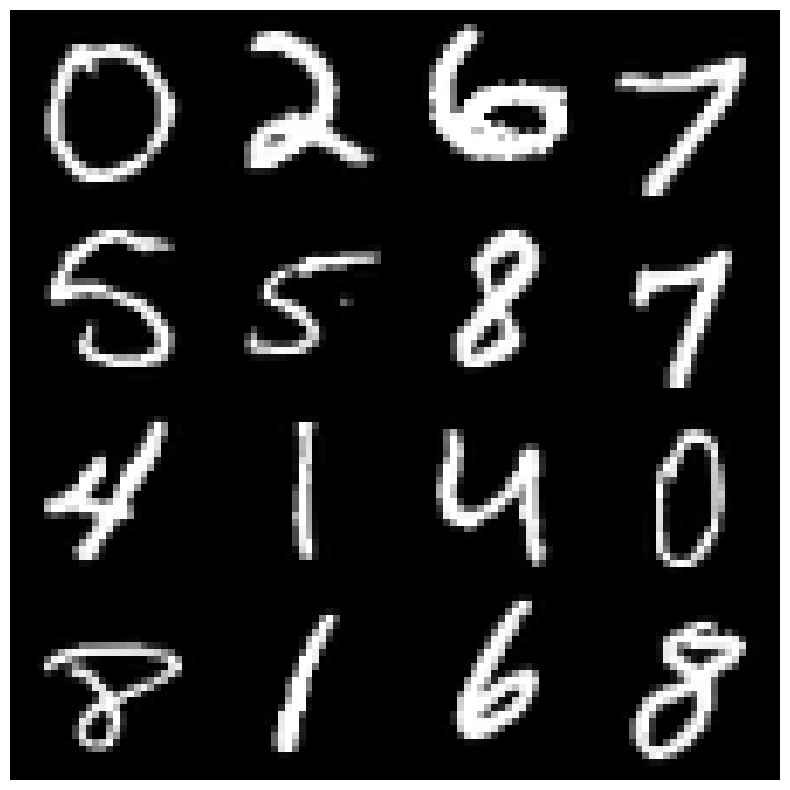

In [7]:
images = next(datastream)[:16,:,:,0]
stacked_images = np.vstack([np.hstack(images[i*4:(i+1)*4]) for i in range(4)])

plt.figure(figsize=(10, 10))
plt.imshow(stacked_images, cmap="gray")
plt.axis('off')
plt.show()


In [8]:
from probjax.nn.nets.unets import UNet, Conv, ConvTranspose, ResnetBlock, ResizeConv
from functools import partial
import time

In [9]:
xs = []
for i in range(5000):
    xs.append(next(datastream))
    time.sleep(0.001)


std1 = np.concatenate(xs, axis=0).std(0)
mu1 = np.concatenate(xs, axis=0).mean(0)
del xs

In [10]:
shapes = [(16,16), (8,8),(4,4)]
conv_up_cls = [partial(ResizeConv, out_shape=shape) for shape in shapes]
conv_down_cls = [partial(ResizeConv, out_shape=shape)for shape in shapes]

# Alternatively try ConvTranspose
# conv_up_cls = partial(ConvTranspose, kernel_size=(3,3))
# conv_down_cls = partial(Conv, kernel_size=(3,3))

In [11]:

class Denoiser(nnx.Module):
    def __init__(self, rngs) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,512, rngs=rngs, learnable=True)
        # Pass norm=nnx.GroupNorm instead of num_groups to UNet/ResnetBlock
        self.net = UNet(
            1,
            rngs=rngs,
            kernel_size=(2,2),
            strides=(1,1),
            kernel_size_resnet=(4,4),
            out_features=[128,256,384,512],
            context_features=512,
            use_attention=[False, False,True,True],
            conv_down_cls = conv_down_cls,
            conv_up_cls = conv_up_cls,
            dtype=jnp.bfloat16,
            precision="BF16_BF16_F32",
            preferred_element_type=jnp.float32,
        )

    def __call__(self, t, x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        out = self.net(x, context=time_embed, *args, **kwargs)
        return out

net = Denoiser(nnx.Rngs(0))
model = LinearFlow(net, std1=std1, mu1=mu1)
params = nnx.state(model, nnx.Param)

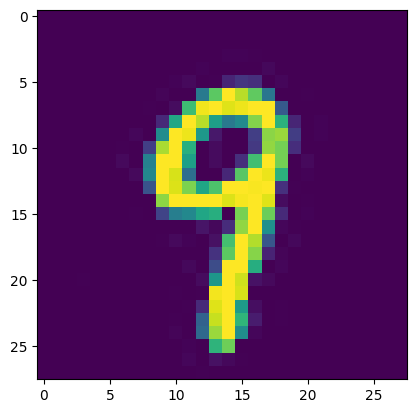

Could not load symbol cuFuncGetName. Error: /lib64/libcuda.so.1: undefined symbol: cuFuncGetName


Down: (256, 28, 28, 128)


2025-09-12 10:04:14.357334: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (bf16[256,16,16,256]{3,2,1,0}, u8[0]{0}) custom-call(bf16[256,19,19,256]{3,2,1,0}, bf16[256,4,4,256]{3,2,1,0}), window={size=4x4}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-09-12 10:04:14.783810: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.426557245s
Trying algorithm eng0{} for conv (bf16[256,16,16,256]{3,2,1,0}, u8[0]{0}) custom-call(bf16[256,19,19,256]{3,2,1,0}, bf16[256,4,4,256]{3,2,1,0}), window={size=4x4}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues"

Down: (256, 16, 16, 256)
Down: (256, 8, 8, 384)
Mid: (256, 4, 4, 512)
Up: (256, 4, 4, 384)


2025-09-12 10:04:29.354171: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (bf16[256,8,8,384]{3,2,1,0}, u8[0]{0}) custom-call(bf16[256,11,11,768]{3,2,1,0}, bf16[384,4,4,768]{3,2,1,0}), window={size=4x4}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-09-12 10:04:29.983709: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.629631415s
Trying algorithm eng0{} for conv (bf16[256,8,8,384]{3,2,1,0}, u8[0]{0}) custom-call(bf16[256,11,11,768]{3,2,1,0}, bf16[384,4,4,768]{3,2,1,0}), window={size=4x4}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],

Up: (256, 8, 8, 256)


2025-09-12 10:04:32.900693: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (bf16[256,16,16,256]{3,2,1,0}, u8[0]{0}) custom-call(bf16[256,19,19,512]{3,2,1,0}, bf16[256,4,4,512]{3,2,1,0}), window={size=4x4}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-09-12 10:04:34.991956: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 3.091328109s
Trying algorithm eng0{} for conv (bf16[256,16,16,256]{3,2,1,0}, u8[0]{0}) custom-call(bf16[256,19,19,512]{3,2,1,0}, bf16[256,4,4,512]{3,2,1,0}), window={size=4x4}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues"

Up: (256, 16, 16, 128)


2025-09-12 10:04:40.976363: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (bf16[256,28,28,128]{3,2,1,0}, u8[0]{0}) custom-call(bf16[256,31,31,256]{3,2,1,0}, bf16[128,4,4,256]{3,2,1,0}), window={size=4x4}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-09-12 10:04:42.168015: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 2.191740696s
Trying algorithm eng0{} for conv (bf16[256,28,28,128]{3,2,1,0}, u8[0]{0}) custom-call(bf16[256,31,31,256]{3,2,1,0}, bf16[128,4,4,256]{3,2,1,0}), window={size=4x4}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues"

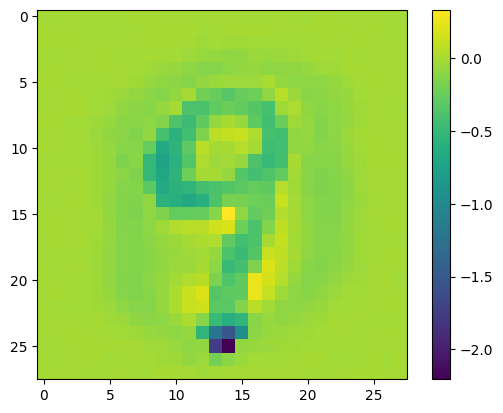

In [12]:
x = next(datastream)
plt.imshow(x[0])
plt.show()
plt.imshow(model(jnp.ones((256,1,1,1))*0.5,x,verbose=True)[0])
plt.colorbar()

In [13]:
# Count parameters
print("Number of parameters: ", sum(np.prod(v.shape) for v in jax.tree_util.tree_leaves(params)))

Number of parameters:  64798624


In [14]:
def loss_fn(params, x, rng):
    nnx.update(model, params)
    return model.loss(rng, x, axis=(-3,-2,-1), adaptive_weight_p=0.8, adaptive_weight_eps=1e-3)


In [15]:
from functools import partial
import optax

opt = optax.chain(optax.adaptive_grad_clip(5.), optax.radam(1e-4))
opt_state = opt.init(params)

@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, x, rng)
    updates, opt_state = opt.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

def train_step(params, opt_state, xs, rng):
    params, opt_state, losses = update(params, opt_state, xs, rng)
    return params, opt_state, jnp.mean(losses)


In [16]:
key = jax.random.key(2)

In [17]:
params, opt_state, loss = train_step(params, opt_state, next(datastream), key)

2025-09-12 10:05:14.704434: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (bf16[256,29,29,128]{3,2,1,0}, u8[0]{0}) custom-call(bf16[256,28,28,128]{3,2,1,0}, bf16[128,4,4,128]{3,2,1,0}), window={size=4x4 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-09-12 10:05:14.786670: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.082345122s
Trying algorithm eng0{} for conv (bf16[256,29,29,128]{3,2,1,0}, u8[0]{0}) custom-call(bf16[256,28,28,128]{3,2,1,0}, bf16[128,4,4,128]{3,2,1,0}), window={size=4x4 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queu

In [18]:
ema = optax.ema(0.9999)
ema_state = ema.init(params)

In [33]:
# Example training iteration
for i in range(100):
    l = 0.
    for j in range(500):
        key, key_data, key_loss = jax.random.split(key, 3)
        xs = next(datastream)
        params, opt_state, loss = train_step(params, opt_state, xs, key_loss)
        l += loss
        ema_params, ema_state = ema.update(params, ema_state)
    print(l/500)

2.4648461
2.4669566
2.4656885
2.4644136
2.46653
2.465171
2.4639454
2.465685
2.4652908
2.4648116
2.4627116
2.4643464
2.4650664
2.4642076
2.4627712
2.4617522
2.4639206
2.4609084
2.461526
2.463529
2.4611068
2.461794
2.4623022
2.4618478
2.462202
2.4615521
2.461696
2.4610353
2.4595292
2.4606743
2.4612067
2.4600403
2.4580755
2.460361
2.45941
2.4604151
2.4581447
2.4602315
2.4575968
2.4594727
2.4590542
2.456435
2.4583285
2.4578614
2.4574046
2.4588952
2.457672
2.455304
2.4576137
2.4554727
2.4579768
2.457502
2.4543364
2.4575365
2.455157
2.45566
2.4545422
2.455629
2.4547937
2.455392
2.4568875
2.4579556
2.4517329
2.4556522
2.4539516
2.4548924
2.455643
2.4536457


KeyboardInterrupt: 

In [34]:
nnx.update(model, ema_params)

In [35]:
from probjax.utils.odeint import odeint



def sample(rng):
    eps = jax.random.normal(rng, (28,28,1,)) * model.std0.value + model.mu0.value
    ts = model.solve_schedule(100)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        v = model(t, x)
        return v.reshape(x.shape)

    return odeint(drift, eps,ts, method="euler")[-1]


In [36]:
keys = jax.random.split(jax.random.key(0), (64,))

In [37]:
xs = jax.vmap(sample)(keys)

In [38]:
xs.min(),xs.max()

(Array(-1.339, dtype=float32), Array(1.449, dtype=float32))

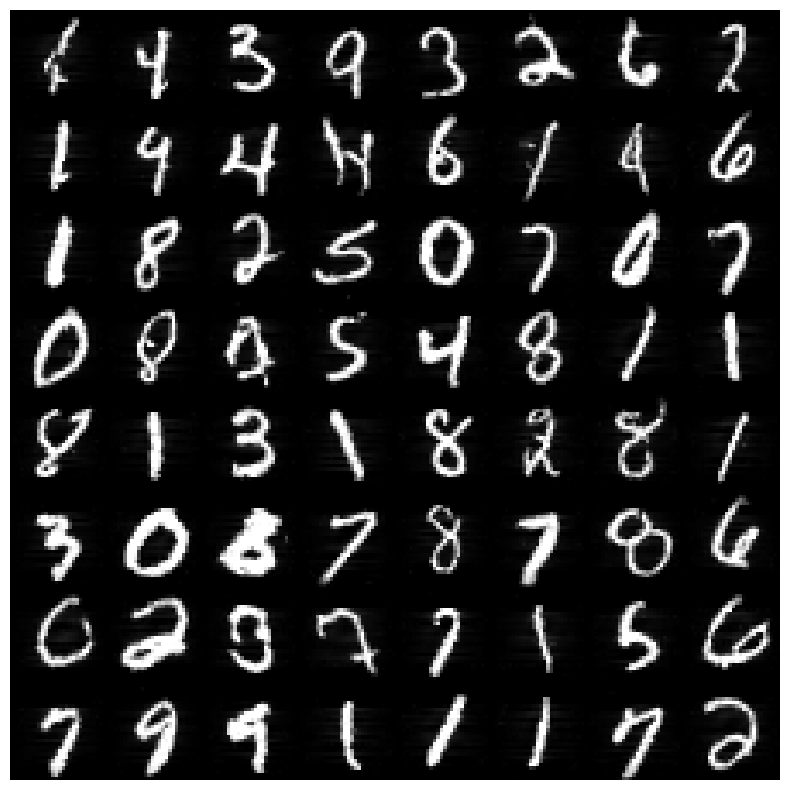

In [39]:
import matplotlib.pyplot as plt


img = xs.reshape(8, 8, 28, 28).transpose(0, 2, 1, 3).reshape(8*28, 8*28)
plt.figure(figsize=(10, 10))
plt.imshow(img, cmap="gray", vmin=-1, vmax=1)
plt.axis('off')
plt.show()